# Updated Phantom CT Radiomics Robustness Notebook

Main CCR phantom workflow with stricter controlled target grouping, CV, SI, blooming, PCA, and reproducibility manifest.

**Important before running:** update the path configuration cell for your local machine. Keep `params_clean_updated.yaml` in the same working directory as this notebook, or edit the `RADIOMICS_YAML` path.

**Methodology notes:** CV remains the primary stability-screening metric. Susceptibility Index (SI) is supplementary. Any LDA step is fitted only inside training folds/splits to avoid leakage.


In [4]:
# Updated Phantom CT Radiomics Robustness Notebook
# CV + Susceptibility Index (SI) + controlled target grouping + blooming + PCA
# Author: Dean H. Cruz
#
# Main scientific intent:
# - Preserve the original phantom workflow.
# - Make target grouping stricter and reproducible.
# - Keep CV as the primary stability metric.
# - Add SI as a supplementary sensitivity metric.
# - Interpret blooming as kernel-associated volume differences under the final workflow.

## 0. Imports and configuration

In [5]:
from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt
import seaborn as sns

from radiomics import featureextractor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# =========================
# USER PATHS
# =========================
DATASET_ROOT = Path(
    r"C:\Users\Ideanuodo\Desktop\THESIS\DataSet\manifest-1551287790971\CC-Radiomics-Phantom-2"
)

OUT_DIR = Path(r"C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Use the same YAML for phantom and Lung1 extraction.
# Rename this path if your actual file is "params_clean(4).yaml".
RADIOMICS_YAML = Path(r"C:\Users\Ideanuodo\Desktop\Updated Code\params_clean_updated.yaml")

# Reference series used for mask definition.
# Keep this fixed across thesis reruns unless you intentionally re-anchor the workflow.
REFERENCE_ROW_INDEX = 0

# Parameter perturbations evaluated in this thesis.
PARAMS_TO_ANALYZE = ["ReconstructionKernel", "Exposure_mAs"]

# External mask-cleaning threshold.
# This is separate from the PyRadiomics YAML resegmentRange.
# Purpose: remove obvious air/background after rigid mask propagation.
MASK_REFINE_HU_LO = -700
MASK_REFINE_HU_HI = 3000

# Minimum ROI size after mask propagation/refinement.
MIN_ROI_VOXELS = 10

# Controlled target requirements.
MIN_SERIES_PER_TARGET = 2
MIN_TARGETS_REQUIRED = 5

# CV settings.
# False preserves your original approach: CV from all rows in each controlled target group.
# True computes CV across parameter-level means, which can reduce imbalance across parameter levels.
# Keep False unless you explicitly decide to revise the thesis results around level-mean CV.
CV_USE_PARAMETER_LEVEL_MEANS = False
CV_EPS = 1e-12

# Stability thresholds.
STRICT_CV_THRESHOLD = 0.05     # 5% CV
RELAXED_CV_THRESHOLD = 0.10    # 10% CV, used for the main ML demonstration
SI_THRESHOLD_PCT = 20.0        # SI < 20% is commonly interpreted as low susceptibility
SI_REF_EPS = 1e-8

# Columns held constant during controlled target construction.
# Layer is appended automatically before target grouping.
#
# Result-altering change:
# Kernel comparisons now hold mAs and voxel geometry fixed.
# mAs comparisons now hold kernel and voxel geometry fixed.
FIXED_COLS_BY_PARAM = {
    "ReconstructionKernel": [
        "Manufacturer", "Model", "KVP",
        "Exposure_mAs",
        "SliceThickness", "PixelSpacing_x", "PixelSpacing_y",
        "Pitch",
    ],
    "Exposure_mAs": [
        "Manufacturer", "Model", "KVP",
        "ReconstructionKernel",
        "SliceThickness", "PixelSpacing_x", "PixelSpacing_y",
        "Pitch",
    ],
}

# Preferred reference kernels for SI.
# If none are present inside a controlled target group, the most frequent kernel in that group is used.
KERNEL_REFERENCE_PRIORITY = [
    "STANDARD", "SOFT",
    "B30f", "B31f", "B31s",
    "I30f", "I31f", "I31s", "I26f",
]

RANDOM_SEED = 42

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [6]:
# ==========================================
# Organized output folders
# ==========================================

OUT_DIR = Path(r"C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean") 
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_SERIES_INDEX = OUT_DIR / "01_series_index"
OUT_REG_QC = OUT_DIR / "02_registration_qc"
OUT_FEATURES = OUT_DIR / "03_feature_extraction"
OUT_TARGETS = OUT_DIR / "04_target_grouping"
OUT_CV = OUT_DIR / "05_cv_analysis"
OUT_SI = OUT_DIR / "06_si_analysis"
OUT_ROBUST = OUT_DIR / "07_robust_feature_selection"
OUT_PCA = OUT_DIR / "08_pca"
OUT_BLOOMING = OUT_DIR / "09_blooming_optional"
OUT_MANIFEST = OUT_DIR / "10_manifest"
OUT_FIGURES = OUT_DIR / "figures"

OUTPUT_FOLDERS = [
    OUT_SERIES_INDEX,
    OUT_REG_QC,
    OUT_FEATURES,
    OUT_TARGETS,
    OUT_CV,
    OUT_SI,
    OUT_ROBUST,
    OUT_PCA,
    OUT_BLOOMING,
    OUT_MANIFEST,
    OUT_FIGURES,
]

for folder in OUTPUT_FOLDERS:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folders created under:")
print(OUT_DIR.resolve())

Output folders created under:
C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean


In [7]:
# ==========================================
# Common output file paths
# ==========================================

SERIES_INDEX_CSV = OUT_SERIES_INDEX / "series_index.csv"

FEATURES_LAYERS_CSV = OUT_FEATURES / "features_layers.csv"
FEATURES_FINAL_LAYERS_CSV = OUT_FEATURES / "features_final_layers.csv"

ROBUST_CV_CSV = OUT_ROBUST / "robust_features_overall_cv.csv"
ROBUST_CV_SI_CSV = OUT_ROBUST / "robust_features_overall_cv_si.csv"

MANIFEST_JSON = OUT_MANIFEST / "run_manifest_phantom_cv_si.json"

## 1. Utility functions

In [8]:
def safe_get(ds, name, default=None):
    """Read a DICOM attribute safely."""
    return getattr(ds, name, default)


def find_series_folders(root: Path, min_dicom_files: int = 10) -> list[Path]:
    """
    Find folders that likely contain CT DICOM series.

    Uses a simple folder-level criterion to avoid treating individual scout/localizer files
    as complete CT volumes.
    """
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"DATASET_ROOT does not exist: {root}")

    series_folders = []
    for p in sorted(root.rglob("*")):
        if not p.is_dir():
            continue
        n_dcm = len(list(p.glob("*.dcm")))
        if n_dcm >= min_dicom_files:
            series_folders.append(p)

    if not series_folders:
        raise RuntimeError(
            "No DICOM series folders found. Check DATASET_ROOT and DICOM folder structure."
        )

    return series_folders


def first_dicom_file(series_folder: Path) -> Path | None:
    """Return the first DICOM file in a series folder."""
    files = sorted(Path(series_folder).glob("*.dcm"))
    return files[0] if files else None


def clean_kernel_label(value) -> str:
    """
    Normalize kernel labels for grouping and plotting.

    This does not change the image data. It only prevents visually identical or messy
    string encodings from being treated as different categories.
    """
    if pd.isna(value):
        return ""
    s = str(value).strip()

    # Handle strings such as "['I26f', '2']" by keeping the first kernel-like token.
    if s.startswith("[") and s.endswith("]"):
        tokens = re.findall(r"[A-Za-z]+\d+[A-Za-z]*|STANDARD|SOFT|BONE|LUNG", s, flags=re.IGNORECASE)
        if tokens:
            return tokens[0]

    return s


def read_series_metadata(series_folder: Path) -> dict:
    """Read lightweight metadata from the first DICOM slice of a series."""
    fp = first_dicom_file(series_folder)
    if fp is None:
        return {"series_path": str(series_folder), "n_files": 0}

    ds = pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)

    px = safe_get(ds, "PixelSpacing", None)
    try:
        px_x = float(px[0]) if px is not None else np.nan
        px_y = float(px[1]) if px is not None else np.nan
    except Exception:
        px_x, px_y = np.nan, np.nan

    def to_float(x):
        try:
            return float(x)
        except Exception:
            return np.nan

    kernel = safe_get(ds, "ConvolutionKernel", safe_get(ds, "ReconstructionKernel", ""))

    return {
        "series_path": str(series_folder),
        "SeriesInstanceUID": str(safe_get(ds, "SeriesInstanceUID", "")).strip(),
        "Manufacturer": str(safe_get(ds, "Manufacturer", "")).strip(),
        "Model": str(safe_get(ds, "ManufacturerModelName", "")).strip(),
        "ReconstructionKernel": clean_kernel_label(kernel),
        "PixelSpacing_x": px_x,
        "PixelSpacing_y": px_y,
        "SliceThickness": to_float(safe_get(ds, "SliceThickness", np.nan)),
        "KVP": to_float(safe_get(ds, "KVP", np.nan)),
        "XRayTubeCurrent_mA": to_float(safe_get(ds, "XRayTubeCurrent", np.nan)),
        "Exposure_mAs": to_float(safe_get(ds, "Exposure", safe_get(ds, "ExposureInuAs", np.nan))),
        "Pitch": to_float(safe_get(ds, "SpiralPitchFactor", np.nan)),
        "n_files": len(list(Path(series_folder).glob("*.dcm"))),
    }


def load_dicom_series(series_folder: Path) -> sitk.Image:
    """Load a DICOM CT series into a 3D SimpleITK image."""
    reader = sitk.ImageSeriesReader()
    names = reader.GetGDCMSeriesFileNames(str(series_folder))
    if not names:
        raise RuntimeError(f"No readable DICOM series found in: {series_folder}")
    reader.SetFileNames(names)
    return reader.Execute()


def save_nifti(img: sitk.Image, path: Path) -> None:
    """Save a SimpleITK image as NIfTI."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    sitk.WriteImage(img, str(path))


def make_cube_mask(
    reference_img: sitk.Image,
    center_ijk: tuple[int, int, int],
    half_size_vox: int = 10,
) -> sitk.Image:
    """
    Create one cubic binary VOI on the reference image grid.

    center_ijk follows SimpleITK index convention: (x, y, z).
    NumPy array order is converted internally to (z, y, x).
    """
    arr = np.zeros(sitk.GetArrayFromImage(reference_img).shape, dtype=np.uint8)
    zmax, ymax, xmax = arr.shape

    i, j, k = center_ijk
    x0, x1 = max(0, i - half_size_vox), min(xmax - 1, i + half_size_vox)
    y0, y1 = max(0, j - half_size_vox), min(ymax - 1, j + half_size_vox)
    z0, z1 = max(0, k - half_size_vox), min(zmax - 1, k + half_size_vox)

    arr[z0:z1 + 1, y0:y1 + 1, x0:x1 + 1] = 1

    mask = sitk.GetImageFromArray(arr)
    mask.CopyInformation(reference_img)
    return sitk.Cast(mask, sitk.sitkUInt8)


def register_rigid(fixed: sitk.Image, moving: sitk.Image, seed: int = 0) -> tuple[sitk.Transform, float]:
    """
    Canonical 3D rigid registration used for BOTH QC and extraction.

    fixed  = target CT scan
    moving = reference CT scan

    Returns a transform that maps moving/reference space into fixed/target space.
    Mattes mutual information is used because kernel changes can alter intensity
    distributions while preserving overall phantom geometry.
    """
    if fixed.GetDimension() != 3 or moving.GetDimension() != 3:
        raise ValueError(
            f"Rigid registration expects 3D images. fixed={fixed.GetDimension()}, moving={moving.GetDimension()}"
        )

    fixed_f = sitk.Cast(fixed, sitk.sitkFloat32)
    moving_f = sitk.Cast(moving, sitk.sitkFloat32)

    initial = sitk.CenteredTransformInitializer(
        fixed_f,
        moving_f,
        sitk.Euler3DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY,
    )

    reg = sitk.ImageRegistrationMethod()
    reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    reg.SetMetricSamplingStrategy(reg.RANDOM)
    reg.SetMetricSamplingPercentage(0.02, seed=seed)
    reg.SetInterpolator(sitk.sitkLinear)

    reg.SetOptimizerAsRegularStepGradientDescent(
        learningRate=2.0,
        minStep=1e-3,
        numberOfIterations=150,
        gradientMagnitudeTolerance=1e-8,
    )
    reg.SetOptimizerScalesFromPhysicalShift()

    reg.SetShrinkFactorsPerLevel([4, 2, 1])
    reg.SetSmoothingSigmasPerLevel([2, 1, 0])
    reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    reg.SetInitialTransform(initial, inPlace=False)
    final_transform = reg.Execute(fixed_f, moving_f)

    return final_transform, float(reg.GetMetricValue())


def warp_mask_to_fixed_space(
    mask_moving: sitk.Image,
    fixed: sitk.Image,
    moving_to_fixed: sitk.Transform,
) -> sitk.Image:
    """Resample a reference-space binary mask into the target CT space."""
    return sitk.Resample(
        mask_moving,
        fixed,
        moving_to_fixed,
        sitk.sitkNearestNeighbor,
        0,
        sitk.sitkUInt8,
    )


def refine_mask_by_hu(
    image: sitk.Image,
    mask: sitk.Image,
    lower_hu: float,
    upper_hu: float,
) -> sitk.Image:
    """
    Refine propagated mask by keeping only voxels inside the chosen HU window.

    This is a preprocessing mask-cleaning step, not the same thing as PyRadiomics
    discretization or the YAML resegmentRange.
    """
    image_f = sitk.Cast(image, sitk.sitkFloat32)
    threshold_mask = sitk.BinaryThreshold(
        image_f,
        lowerThreshold=lower_hu,
        upperThreshold=upper_hu,
        insideValue=1,
        outsideValue=0,
    )
    return sitk.Cast(sitk.And(mask > 0, threshold_mask > 0), sitk.sitkUInt8)


def voxel_count(mask: sitk.Image) -> int:
    """Count nonzero voxels in a binary mask."""
    return int(sitk.GetArrayViewFromImage(mask).sum())


def physical_volume_mm3(mask: sitk.Image) -> float:
    """Compute physical mask volume in mm^3."""
    return voxel_count(mask) * float(np.prod(mask.GetSpacing()))


def feature_family(name: str) -> str:
    """Extract PyRadiomics feature family from feature name."""
    parts = str(name).split("_")
    return parts[1] if len(parts) >= 3 else "unknown"


def standardize_grouping_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize metadata used in controlled target grouping.

    Rounding prevents tiny float representation differences from splitting
    otherwise identical acquisition settings into separate groups.
    """
    d = df.copy()

    if "ReconstructionKernel" in d.columns:
        d["ReconstructionKernel"] = d["ReconstructionKernel"].map(clean_kernel_label)

    for c in ["KVP", "Exposure_mAs", "SliceThickness", "PixelSpacing_x", "PixelSpacing_y", "Pitch"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce").round(5)

    for c in ["Manufacturer", "Model", "Layer"]:
        if c in d.columns:
            d[c] = d[c].astype(str).str.strip()

    return d

## 2. Build or load DICOM metadata index

In [9]:
#index_csv = OUT_DIR / "series_index.csv"
index_csv = OUT_SERIES_INDEX / "series_index.csv"

if index_csv.exists():
    df_idx = pd.read_csv(index_csv)
    print(f"Loaded cached index: {index_csv} rows={len(df_idx)}")
else:
    folders = find_series_folders(DATASET_ROOT)
    rows = []

    for i, folder in enumerate(folders):
        if i % 25 == 0:
            print(f"Indexing {i}/{len(folders)}")
        try:
            rows.append(read_series_metadata(folder))
        except Exception as e:
            rows.append({"series_path": str(folder), "metadata_error": str(e), "n_files": 0})

    df_idx = pd.DataFrame(rows)
    df_idx = standardize_grouping_columns(df_idx)
    df_idx.to_csv(index_csv, index=False)
    print(f"Saved index: {index_csv} rows={len(df_idx)}")

display(df_idx.head())

Loaded cached index: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean\01_series_index\series_index.csv rows=251


,series_path,SeriesInstanceUID,Manufacturer,Model,ReconstructionKernel,PixelSpacing_x,PixelSpacing_y,SliceThickness,KVP,XRayTubeCurrent_mA,Exposure_mAs,Pitch,n_files
0,C:\Users\Ideanuodo\Desktop\THESIS\DataSet\mani...,1.3.6.1.4.1.14519.5.2.1.4221.6935.193572537116...,GE MEDICAL SYSTEMS,Discovery STE,STANDARD,0.39062,0.39062,1.25,120.0,250.0,7.0,0.98438,301
1,C:\Users\Ideanuodo\Desktop\THESIS\DataSet\mani...,1.3.6.1.4.1.14519.5.2.1.4221.6935.234607076571...,GE MEDICAL SYSTEMS,Discovery STE,STANDARD,0.48828,0.48828,1.25,120.0,250.0,7.0,0.98438,301
2,C:\Users\Ideanuodo\Desktop\THESIS\DataSet\mani...,1.3.6.1.4.1.14519.5.2.1.4221.6935.986713803611...,GE MEDICAL SYSTEMS,Discovery STE,STANDARD,0.58594,0.58594,1.25,120.0,250.0,7.0,0.98438,301
3,C:\Users\Ideanuodo\Desktop\THESIS\DataSet\mani...,1.3.6.1.4.1.14519.5.2.1.4221.6935.766647132115...,GE MEDICAL SYSTEMS,Discovery STE,STANDARD,0.68359,0.68359,1.25,120.0,250.0,7.0,0.98438,301
4,C:\Users\Ideanuodo\Desktop\THESIS\DataSet\mani...,1.3.6.1.4.1.14519.5.2.1.4221.6935.316020374649...,GE MEDICAL SYSTEMS,Discovery STE,STANDARD,0.78125,0.78125,1.25,120.0,250.0,7.0,0.98438,301


## 3. Select global reference CT and create layer-specific reference masks

In [10]:
ref_row = df_idx.iloc[int(REFERENCE_ROW_INDEX)]
ref_path = Path(ref_row["series_path"])

print("Reference series folder:", ref_path)
ref_img = load_dicom_series(ref_path)

print("Reference image size (x,y,z):", ref_img.GetSize())
print("Reference spacing (mm):", ref_img.GetSpacing())

# Layer-specific cubic VOI centers.
# Keep these fixed once finalized to preserve reproducibility.
cx = (ref_img.GetSize()[0] // 2) - 5
cy = (ref_img.GetSize()[1] // 2) + 10

cube_centers_ijk = {
    "20% Filled ABS": (cx, cy, 274),
    "30% Filled ABS": (cx, cy, 248),
    "40% Filled ABS": (cx, cy, 222),
    "50% Filled ABS": (cx, cy, 198),
    "Sycamore Wood": (cx, cy, 169),
    "Rubber Particles": (cx, cy, 144),
    "Dense Cork": (cx, cy, 119),
    "Solid Acrylic": (cx, cy, 91),
    "Natural Cork": (cx, cy, 67),
    "Plaster Resin": (cx, cy, 41),
}

ref_masks_dict = {}
for layer_name, center in cube_centers_ijk.items():
    ref_masks_dict[layer_name] = make_cube_mask(ref_img, center, half_size_vox=10)

save_nifti(ref_img, OUT_REG_QC / "reference_ct.nii.gz")

for layer_name, mask in ref_masks_dict.items():
    safe_name = layer_name.replace(" ", "_").replace("%", "pct")
    save_nifti(mask, OUT_REG_QC / f"reference_mask_{safe_name}.nii.gz")

print(f"Saved reference CT and {len(ref_masks_dict)} layer masks.")

Reference series folder: C:\Users\Ideanuodo\Desktop\THESIS\DataSet\manifest-1551287790971\CC-Radiomics-Phantom-2\CCR-2-0001\03-29-2016-NA-Unspecified CT-04822\6.000000-GEDiscoverySTE1202501.25200-33050
Reference image size (x,y,z): (512, 512, 301)
Reference spacing (mm): (0.390625, 0.390625, 1.25)
Saved reference CT and 10 layer masks.


## 4. Feature extraction with canonical registration and HU mask refinement

In [11]:
# ==========================================
# Phantom radiomics feature extraction with caching and progress bar
# Outputs:
#   features_layers.csv        -> OUT_FEATURES
#   registration_qc.csv        -> OUT_REG_QC
# ==========================================

from time import perf_counter
from tqdm.auto import tqdm

features_path = OUT_FEATURES / "features_layers.csv"
qc_path = OUT_REG_QC / "registration_qc.csv"

FORCE_RERUN_EXTRACTION = False  # Set True only if you want to recompute features


def format_seconds(seconds: float) -> str:
    """
    Converts seconds into a readable format.
    """
    seconds = int(max(seconds, 0))
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60

    if h > 0:
        return f"{h}h {m}m {s}s"
    if m > 0:
        return f"{m}m {s}s"
    return f"{s}s"


if (
    not FORCE_RERUN_EXTRACTION
    and features_path.exists()
    and qc_path.exists()
):
    print("Found cached phantom features and QC logs.")
    print("Features:", features_path.resolve())
    print("QC:", qc_path.resolve())

    df_feat = pd.read_csv(features_path)
    df_qc = pd.read_csv(qc_path)


else:
    if not RADIOMICS_YAML.exists():
        raise FileNotFoundError(
            f"PyRadiomics YAML not found: {RADIOMICS_YAML.resolve()}"
        )

    extractor = featureextractor.RadiomicsFeatureExtractor(str(RADIOMICS_YAML))

    def extract_feature_vector(img: sitk.Image, mask: sitk.Image) -> dict:
        """
        Runs PyRadiomics feature extraction.

        Diagnostics fields are removed because they are not radiomic features
        and can unnecessarily enlarge the saved table.
        """
        result = extractor.execute(img, mask, label=1)

        clean = {}

        for k, v in result.items():
            if str(k).startswith("diagnostics"):
                continue

            try:
                clean[str(k)] = float(v)
            except Exception:
                clean[str(k)] = np.nan

        return clean

    features = []
    qc_rows = []

    total_series = len(df_idx)
    total_layers = len(ref_masks_dict)
    total_extractions = total_series * total_layers

    print(
        f"Starting extraction on {total_series} series "
        f"x {total_layers} layers = {total_extractions} possible extractions"
    )

    start_time = perf_counter()

    completed_series = 0
    attempted_extractions = 0
    successful_extractions = 0
    skipped_small_roi = 0
    failed_series = 0

    # Outer progress bar tracks scan-level progress.
    series_bar = tqdm(
        df_idx.iterrows(),
        total=total_series,
        desc="Processing CT series",
        unit="series",
        dynamic_ncols=True,
    )

    for r, row in series_bar:
        series_path = Path(row["series_path"])
        series_name = series_path.name

        try:
            # ------------------------------------------
            # Load target CT image
            # ------------------------------------------
            fixed_img = load_dicom_series(series_path)

            # ------------------------------------------
            # Register once per scan
            # This transform is reused for all material layers.
            # ------------------------------------------
            transform, metric = register_rigid(
                fixed=fixed_img,
                moving=ref_img,
                seed=RANDOM_SEED,
            )

            # ------------------------------------------
            # Extract features for each material layer
            # ------------------------------------------
            for layer_name, ref_mask in ref_masks_dict.items():
                attempted_extractions += 1

                warped_mask = warp_mask_to_fixed_space(
                    ref_mask,
                    fixed_img,
                    transform,
                )

                refined_mask = refine_mask_by_hu(
                    fixed_img,
                    warped_mask,
                    lower_hu=MASK_REFINE_HU_LO,
                    upper_hu=MASK_REFINE_HU_HI,
                )

                n_before = voxel_count(warped_mask)
                n_after = voxel_count(refined_mask)

                qc_entry = {
                    "series_path": str(series_path),
                    "SeriesInstanceUID": row.get("SeriesInstanceUID", ""),
                    "Layer": layer_name,
                    "registration_metric": metric,
                    "roi_voxels_before_refine": n_before,
                    "roi_voxels_after_refine": n_after,
                    "roi_volume_mm3_after_refine": physical_volume_mm3(refined_mask),
                    "passed_roi_qc": n_after > MIN_ROI_VOXELS,
                    "error": "",
                }

                if n_after <= MIN_ROI_VOXELS:
                    skipped_small_roi += 1
                    qc_rows.append(qc_entry)
                    continue

                # ------------------------------------------
                # PyRadiomics extraction
                # ------------------------------------------
                fv = extract_feature_vector(fixed_img, refined_mask)

                fv.update({
                    "series_path": str(series_path),
                    "SeriesInstanceUID": row.get("SeriesInstanceUID", ""),
                    "Layer": layer_name,
                })

                features.append(fv)
                qc_rows.append(qc_entry)

                successful_extractions += 1

                # ------------------------------------------
                # Update progress estimates after each layer
                # ------------------------------------------
                elapsed = perf_counter() - start_time
                avg_sec_per_attempt = elapsed / max(attempted_extractions, 1)
                remaining_attempts = total_extractions - attempted_extractions
                eta = avg_sec_per_attempt * remaining_attempts

                series_bar.set_postfix({
                    "series": f"{completed_series}/{total_series}",
                    "layer": layer_name,
                    "ok": successful_extractions,
                    "skip": skipped_small_roi,
                    "fail_series": failed_series,
                    "elapsed": format_seconds(elapsed),
                    "ETA": format_seconds(eta),
                })

            completed_series += 1

        except Exception as e:
            failed_series += 1

            qc_rows.append({
                "series_path": str(series_path),
                "SeriesInstanceUID": row.get("SeriesInstanceUID", ""),
                "Layer": "",
                "registration_metric": np.nan,
                "roi_voxels_before_refine": np.nan,
                "roi_voxels_after_refine": np.nan,
                "roi_volume_mm3_after_refine": np.nan,
                "passed_roi_qc": False,
                "error": str(e),
            })

            elapsed = perf_counter() - start_time
            avg_sec_per_series = elapsed / max((completed_series + failed_series), 1)
            remaining_series = total_series - (completed_series + failed_series)
            eta = avg_sec_per_series * remaining_series

            series_bar.set_postfix({
                "series": f"{completed_series}/{total_series}",
                "current": series_name,
                "ok": successful_extractions,
                "skip": skipped_small_roi,
                "fail_series": failed_series,
                "elapsed": format_seconds(elapsed),
                "ETA": format_seconds(eta),
            })

    # ==========================================
    # Save extraction outputs
    # ==========================================

    df_feat = pd.DataFrame(features)
    df_qc = pd.DataFrame(qc_rows)

    df_feat.to_csv(features_path, index=False)
    df_qc.to_csv(qc_path, index=False)

    elapsed_total = perf_counter() - start_time

    print("\nExtraction finished.")
    print("Elapsed time:", format_seconds(elapsed_total))
    print("Successful extractions:", successful_extractions)
    print("Skipped small ROIs:", skipped_small_roi)
    print("Failed series:", failed_series)

    print("\nSaved features:")
    print(features_path.resolve())

    print("\nSaved QC:")
    print(qc_path.resolve())


print("\nFeature table:", df_feat.shape)
print("QC table:", df_qc.shape)

Found cached phantom features and QC logs.
Features: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean\03_feature_extraction\features_layers.csv
QC: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean\02_registration_qc\registration_qc.csv

Feature table: (2500, 110)
QC table: (2510, 9)


In [12]:
features_path = OUT_FEATURES / "features_layers.csv"
qc_path = OUT_REG_QC / "registration_qc.csv"

if features_path.exists() and qc_path.exists():
    print("Found cached phantom features and QC logs.")
    df_feat = pd.read_csv(features_path)
    df_qc = pd.read_csv(qc_path)

else:
    if not RADIOMICS_YAML.exists():
        raise FileNotFoundError(f"PyRadiomics YAML not found: {RADIOMICS_YAML.resolve()}")

    extractor = featureextractor.RadiomicsFeatureExtractor(str(RADIOMICS_YAML))

    def extract_feature_vector(img: sitk.Image, mask: sitk.Image) -> dict:
        """Run PyRadiomics and remove diagnostics fields from the saved feature table."""
        result = extractor.execute(img, mask, label=1)
        clean = {}
        for k, v in result.items():
            if k.startswith("diagnostics"):
                continue
            try:
                clean[k] = float(v)
            except Exception:
                clean[k] = np.nan
        return clean

    features = []
    qc_rows = []

    print(f"Starting extraction on {len(df_idx)} series x {len(ref_masks_dict)} layers")

    for r, row in df_idx.iterrows():
        series_path = Path(row["series_path"])

        if r % 10 == 0:
            print(f"Processing scan {r}/{len(df_idx)}: {series_path.name}")

        try:
            fixed_img = load_dicom_series(series_path)

            # Register once per scan, then reuse the transform for all material layers.
            transform, metric = register_rigid(fixed=fixed_img, moving=ref_img, seed=RANDOM_SEED)

            for layer_name, ref_mask in ref_masks_dict.items():
                warped_mask = warp_mask_to_fixed_space(ref_mask, fixed_img, transform)
                refined_mask = refine_mask_by_hu(
                    fixed_img,
                    warped_mask,
                    lower_hu=MASK_REFINE_HU_LO,
                    upper_hu=MASK_REFINE_HU_HI,
                )

                n_before = voxel_count(warped_mask)
                n_after = voxel_count(refined_mask)

                qc_entry = {
                    "series_path": str(series_path),
                    "SeriesInstanceUID": row.get("SeriesInstanceUID", ""),
                    "Layer": layer_name,
                    "registration_metric": metric,
                    "roi_voxels_before_refine": n_before,
                    "roi_voxels_after_refine": n_after,
                    "roi_volume_mm3_after_refine": physical_volume_mm3(refined_mask),
                    "passed_roi_qc": n_after > MIN_ROI_VOXELS,
                    "error": "",
                }

                if n_after <= MIN_ROI_VOXELS:
                    qc_rows.append(qc_entry)
                    continue

                fv = extract_feature_vector(fixed_img, refined_mask)
                fv.update({
                    "series_path": str(series_path),
                    "SeriesInstanceUID": row.get("SeriesInstanceUID", ""),
                    "Layer": layer_name,
                })

                features.append(fv)
                qc_rows.append(qc_entry)

        except Exception as e:
            print(f"Error processing {series_path}: {e}")
            qc_rows.append({
                "series_path": str(series_path),
                "SeriesInstanceUID": row.get("SeriesInstanceUID", ""),
                "Layer": "",
                "registration_metric": np.nan,
                "roi_voxels_before_refine": np.nan,
                "roi_voxels_after_refine": np.nan,
                "roi_volume_mm3_after_refine": np.nan,
                "passed_roi_qc": False,
                "error": str(e),
            })

    df_feat = pd.DataFrame(features)
    df_qc = pd.DataFrame(qc_rows)

    df_feat.to_csv(features_path, index=False)
    df_qc.to_csv(qc_path, index=False)

    print("Saved:", features_path)
    print("Saved:", qc_path)

print("Feature table:", df_feat.shape)
print("QC table:", df_qc.shape)

Found cached phantom features and QC logs.
Feature table: (2500, 110)
QC table: (2510, 9)


## 5. Merge features with metadata and define usable feature columns

In [13]:
df = df_feat.merge(df_idx, on="series_path", how="left", suffixes=("", "_meta"))
df = standardize_grouping_columns(df)

non_feature_cols = {
    "series_path", "SeriesInstanceUID", "Layer", "SeriesInstanceUID_meta",
    "Manufacturer", "Model", "ReconstructionKernel",
    "PixelSpacing_x", "PixelSpacing_y", "SliceThickness",
    "KVP", "XRayTubeCurrent_mA", "Exposure_mAs", "Pitch", "n_files",
}

feature_cols = [
    c for c in df.columns
    if c not in non_feature_cols and pd.api.types.is_numeric_dtype(df[c])
]

# Drop non-informative features.
var = df[feature_cols].var(axis=0, numeric_only=True)
feature_cols = [
    c for c in feature_cols
    if pd.notna(var[c]) and var[c] > 0
]

desired_meta_cols = [
    "series_path", "SeriesInstanceUID", "Layer", "Manufacturer", "Model",
    "KVP", "ReconstructionKernel", "Exposure_mAs",
    "SliceThickness", "PixelSpacing_x", "PixelSpacing_y", "Pitch",
]
available_meta = [c for c in desired_meta_cols if c in df.columns]

df_out = df[available_meta + feature_cols].copy()
df_out.to_csv(OUT_FEATURES / "features_final_layers.csv", index=False)

print("Rows:", len(df_out))
print("Usable radiomics features:", len(feature_cols))
print("Saved:", OUT_FEATURES / "features_final_layers.csv")

Rows: 2500
Usable radiomics features: 107
Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean\03_feature_extraction\features_final_layers.csv


## 6. Controlled target construction, CV, and SI

In [15]:
def fixed_cols_for_param(param_col: str) -> list[str]:
    """Return controlled grouping columns and automatically add Layer."""
    base = list(FIXED_COLS_BY_PARAM.get(param_col, []))
    if "Layer" not in base:
        base.append("Layer")
    return base


def build_targets(
    df_meta: pd.DataFrame,
    param_col: str,
    fixed_cols: list[str],
    min_series: int = MIN_SERIES_PER_TARGET,
) -> list[pd.DataFrame]:
    """
    Split data into controlled target groups.

    A valid target group:
    - has enough rows
    - has at least two levels of the tested parameter
    - keeps fixed_cols constant
    """
    required = [param_col] + fixed_cols
    missing = [c for c in required if c not in df_meta.columns]
    if missing:
        raise ValueError(f"Missing columns for target construction: {missing}")

    d = df_meta.dropna(subset=[param_col]).copy()
    d = standardize_grouping_columns(d)

    targets = []
    for _, g in d.groupby(fixed_cols, dropna=False):
        if len(g) < min_series:
            continue
        if g[param_col].nunique(dropna=True) < 2:
            continue
        targets.append(g.copy())

    return targets


def compute_cv_from_values(x: np.ndarray, eps: float = CV_EPS) -> float:
    """Coefficient of variation as a fraction. Example: 0.05 means 5%."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan

    mu = float(np.mean(x))
    sd = float(np.std(x, ddof=1))

    if abs(mu) < eps:
        return np.nan

    return sd / abs(mu)


def compute_cv_for_target(g: pd.DataFrame, feature: str, param_col: str) -> float:
    """
    Compute feature CV within one controlled target group.

    Default preserves the original approach by using all rows.
    If CV_USE_PARAMETER_LEVEL_MEANS=True, each parameter level contributes equally.
    """
    if CV_USE_PARAMETER_LEVEL_MEANS:
        vals = g.groupby(param_col, dropna=True)[feature].mean().to_numpy(dtype=float)
    else:
        vals = g[feature].to_numpy(dtype=float)

    return compute_cv_from_values(vals)


def choose_reference_level(g: pd.DataFrame, param_col: str):
    """
    Select reference condition for SI calculation inside one controlled target group.

    mAs: highest mAs is used as lower-noise reference.
    Kernel: standard/soft kernels are preferred when available.
    Fallback: most frequent level in that controlled group.
    """
    s = g[param_col].dropna()

    if s.empty:
        return None

    if param_col == "Exposure_mAs":
        numeric_s = pd.to_numeric(s, errors="coerce")
        if numeric_s.notna().sum() == 0:
            return None
        return s.loc[numeric_s.idxmax()]

    if param_col == "ReconstructionKernel":
        levels = list(pd.Series(s.map(clean_kernel_label)).dropna().unique())
        level_lookup = {str(v): v for v in levels}

        for preferred in KERNEL_REFERENCE_PRIORITY:
            if preferred in level_lookup:
                return level_lookup[preferred]

        for keyword in ["STANDARD", "SOFT", "B30", "B31", "I30", "I31"]:
            matches = [name for name in level_lookup if keyword.lower() in name.lower()]
            if matches:
                return level_lookup[sorted(matches)[0]]

        return pd.Series(s).mode().iloc[0]

    return pd.Series(s).mode().iloc[0]


def compute_si_values_for_target(
    g: pd.DataFrame,
    feature: str,
    param_col: str,
    reference_level,
    eps: float = SI_REF_EPS,
) -> list[float]:
    """
    Compute SI values for one feature within one controlled target group.

    SI = |M(altered) - M(reference)| / |M(reference)| x 100

    If the reference mean is near zero, SI is skipped because it becomes unstable.
    """
    gg = g.copy()
    if param_col == "ReconstructionKernel":
        gg[param_col] = gg[param_col].map(clean_kernel_label)

    means = gg.groupby(param_col, dropna=True)[feature].mean()

    if reference_level not in means.index:
        return []

    ref_mean = float(means.loc[reference_level])
    if not np.isfinite(ref_mean) or abs(ref_mean) < eps:
        return []

    out = []
    for level, altered_mean in means.items():
        if level == reference_level:
            continue

        si = abs(float(altered_mean) - ref_mean) / abs(ref_mean) * 100.0
        if np.isfinite(si):
            out.append(si)

    return out


def robustness_cv_for_param(
    df_all: pd.DataFrame,
    feature_cols: list[str],
    param_col: str,
    fixed_cols: list[str],
) -> pd.DataFrame:
    """Compute median CV per feature across controlled target groups."""
    targets = build_targets(df_all, param_col=param_col, fixed_cols=fixed_cols)
    print(f"[{param_col} CV] valid target groups: {len(targets)} | fixed={fixed_cols}")

    if len(targets) < MIN_TARGETS_REQUIRED:
        warnings.warn(f"Skipping {param_col} CV: only {len(targets)} targets found.")
        return pd.DataFrame()

    rows = []

    for feat in feature_cols:
        cvs = []
        for g in targets:
            cv = compute_cv_for_target(g, feat, param_col)
            if np.isfinite(cv):
                cvs.append(cv)

        if not cvs:
            continue

        rows.append({
            "feature": feat,
            "family": feature_family(feat),
            "cv_median": float(np.median(cvs)),
            "cv_min": float(np.min(cvs)),
            "cv_max": float(np.max(cvs)),
            "cv_p90": float(np.percentile(cvs, 90)),
            "n_targets_used": int(len(cvs)),
            "tested_param": param_col,
        })

    return pd.DataFrame(rows).sort_values("cv_median").reset_index(drop=True)


def robustness_si_for_param(
    df_all: pd.DataFrame,
    feature_cols: list[str],
    param_col: str,
    fixed_cols: list[str],
) -> pd.DataFrame:
    """Compute median SI per feature across controlled target groups."""
    targets = build_targets(df_all, param_col=param_col, fixed_cols=fixed_cols)
    print(f"[{param_col} SI] valid target groups: {len(targets)} | fixed={fixed_cols}")

    if len(targets) < MIN_TARGETS_REQUIRED:
        warnings.warn(f"Skipping {param_col} SI: only {len(targets)} targets found.")
        return pd.DataFrame()

    rows = []

    for feat in feature_cols:
        all_si = []
        n_targets_used = 0
        n_reference_failures = 0

        for g in targets:
            ref_level = choose_reference_level(g, param_col)
            if ref_level is None:
                n_reference_failures += 1
                continue

            si_values = compute_si_values_for_target(g, feat, param_col, ref_level)
            if not si_values:
                n_reference_failures += 1
                continue

            all_si.extend(si_values)
            n_targets_used += 1

        if not all_si:
            continue

        rows.append({
            "feature": feat,
            "family": feature_family(feat),
            "si_median_pct": float(np.median(all_si)),
            "si_min_pct": float(np.min(all_si)),
            "si_max_pct": float(np.max(all_si)),
            "si_p90_pct": float(np.percentile(all_si, 90)),
            "n_si_comparisons": int(len(all_si)),
            "n_targets_used": int(n_targets_used),
            "n_reference_failures": int(n_reference_failures),
            "tested_param": param_col,
        })

    return pd.DataFrame(rows).sort_values("si_median_pct").reset_index(drop=True)


def summarize_targets(df_all: pd.DataFrame, param_col: str, fixed_cols: list[str]) -> pd.DataFrame:
    """Create an audit table of controlled target groups."""
    targets = build_targets(df_all, param_col=param_col, fixed_cols=fixed_cols)

    rows = []
    for i, g in enumerate(targets):
        row = {
            "target_id": i,
            "tested_param": param_col,
            "n_rows": len(g),
            "n_param_levels": g[param_col].nunique(dropna=True),
            "param_levels": "; ".join(map(str, sorted(g[param_col].dropna().astype(str).unique()))),
        }
        for c in fixed_cols:
            vals = g[c].dropna().unique()
            row[c] = vals[0] if len(vals) == 1 else "; ".join(map(str, vals[:5]))
        rows.append(row)

    return pd.DataFrame(rows)


# Run CV and SI.
cv_tables = {}
si_tables = {}

for param in PARAMS_TO_ANALYZE:
    fixed_cols = fixed_cols_for_param(param)

    target_summary = summarize_targets(df_out, param, fixed_cols)
    target_summary.to_csv(OUT_TARGETS / f"target_summary_{param}.csv", index=False)
    print(f"Saved target summary for {param}: {target_summary.shape}")

    cv_df = robustness_cv_for_param(df_out, feature_cols, param, fixed_cols)
    if not cv_df.empty:
        cv_tables[param] = cv_df
        cv_df.to_csv(OUT_CV / f"feature_cv_by_{param}.csv", index=False)

    si_df = robustness_si_for_param(df_out, feature_cols, param, fixed_cols)
    if not si_df.empty:
        si_tables[param] = si_df
        si_df.to_csv(OUT_SI / f"feature_si_by_{param}.csv", index=False)

Saved target summary for ReconstructionKernel: (60, 14)
[ReconstructionKernel CV] valid target groups: 60 | fixed=['Manufacturer', 'Model', 'KVP', 'Exposure_mAs', 'SliceThickness', 'PixelSpacing_x', 'PixelSpacing_y', 'Pitch', 'Layer']
[ReconstructionKernel SI] valid target groups: 60 | fixed=['Manufacturer', 'Model', 'KVP', 'Exposure_mAs', 'SliceThickness', 'PixelSpacing_x', 'PixelSpacing_y', 'Pitch', 'Layer']
Saved target summary for Exposure_mAs: (80, 14)
[Exposure_mAs CV] valid target groups: 80 | fixed=['Manufacturer', 'Model', 'KVP', 'ReconstructionKernel', 'SliceThickness', 'PixelSpacing_x', 'PixelSpacing_y', 'Pitch', 'Layer']
[Exposure_mAs SI] valid target groups: 80 | fixed=['Manufacturer', 'Model', 'KVP', 'ReconstructionKernel', 'SliceThickness', 'PixelSpacing_x', 'PixelSpacing_y', 'Pitch', 'Layer']


## 7. Merge CV and SI into one robustness table

In [16]:
if not cv_tables:
    raise RuntimeError("No CV tables were produced. Check target grouping and metadata columns.")

df_overall = None

for param, t in cv_tables.items():
    t2 = t[["feature", "family", "cv_median", "n_targets_used"]].copy()
    t2 = t2.rename(columns={
        "cv_median": f"cv_median_{param}",
        "n_targets_used": f"n_targets_cv_{param}",
    })
    df_overall = t2 if df_overall is None else df_overall.merge(
        t2, on=["feature", "family"], how="outer"
    )

for param, t in si_tables.items():
    t2 = t[["feature", "family", "si_median_pct", "n_si_comparisons"]].copy()
    t2 = t2.rename(columns={
        "si_median_pct": f"si_median_pct_{param}",
        "n_si_comparisons": f"n_si_comparisons_{param}",
    })
    df_overall = df_overall.merge(t2, on=["feature", "family"], how="outer")

cv_cols = [c for c in df_overall.columns if c.startswith("cv_median_")]
si_cols = [c for c in df_overall.columns if c.startswith("si_median_pct_")]

# Conservative summaries:
# - overall_cv is the worst median CV across kernel and mAs tests.
# - overall_si_pct is the worst median SI across kernel and mAs tests.
df_overall["overall_cv"] = df_overall[cv_cols].max(axis=1, skipna=True)
df_overall["overall_si_pct"] = df_overall[si_cols].max(axis=1, skipna=True) if si_cols else np.nan

df_overall["stable_cv_le_0p05"] = df_overall["overall_cv"] <= STRICT_CV_THRESHOLD
df_overall["stable_cv_le_0p10"] = df_overall["overall_cv"] <= RELAXED_CV_THRESHOLD
df_overall["stable_si_lt_20pct"] = df_overall["overall_si_pct"] < SI_THRESHOLD_PCT
df_overall["stable_cv_0p10_and_si_20pct"] = (
    df_overall["stable_cv_le_0p10"] & df_overall["stable_si_lt_20pct"]
)

df_overall = df_overall.sort_values("overall_cv").reset_index(drop=True)

# Save both names:
# - old name preserves compatibility with the ML notebook
# - new name explicitly indicates CV + SI
df_overall.to_csv(OUT_ROBUST / "robust_features_overall_cv.csv", index=False)
df_overall.to_csv(OUT_ROBUST / "robust_features_overall_cv_si.csv", index=False)

print("Saved:", OUT_ROBUST / "robust_features_overall_cv.csv")
print("Saved:", OUT_ROBUST / "robust_features_overall_cv_si.csv")
print("Strict CV <= 0.05:", int(df_overall["stable_cv_le_0p05"].sum()))
print("Relaxed CV <= 0.10:", int(df_overall["stable_cv_le_0p10"].sum()))
print("SI < 20%:", int(df_overall["stable_si_lt_20pct"].sum()))
print("CV <= 0.10 and SI < 20%:", int(df_overall["stable_cv_0p10_and_si_20pct"].sum()))

display(df_overall.head(30))

Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean\07_robust_feature_selection\robust_features_overall_cv.csv
Saved: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean\07_robust_feature_selection\robust_features_overall_cv_si.csv
Strict CV <= 0.05: 17
Relaxed CV <= 0.10: 27
SI < 20%: 37
CV <= 0.10 and SI < 20%: 27


,feature,family,cv_median_ReconstructionKernel,n_targets_cv_ReconstructionKernel,cv_median_Exposure_mAs,n_targets_cv_Exposure_mAs,si_median_pct_ReconstructionKernel,n_si_comparisons_ReconstructionKernel,si_median_pct_Exposure_mAs,n_si_comparisons_Exposure_mAs,overall_cv,overall_si_pct,stable_cv_le_0p05,stable_cv_le_0p10,stable_si_lt_20pct,stable_cv_0p10_and_si_20pct
0,original_shape_Maximum2DDiameterSlice,shape,1.682798e-16,60,1.908113e-16,80,0.000000,240,0.000000,217,1.908113e-16,0.000000,True,True,True,True
1,original_glcm_Idmn,glcm,9.508852e-03,60,3.247218e-03,80,0.886467,240,0.282354,217,9.508852e-03,0.886467,True,True,True,True
2,original_shape_Maximum3DDiameter,shape,1.291257e-02,60,1.263220e-02,80,1.183733,240,0.000000,217,1.291257e-02,1.183733,True,True,True,True
3,original_shape_LeastAxisLength,shape,1.256720e-02,60,1.310469e-02,80,1.509563,240,0.845990,217,1.310469e-02,1.509563,True,True,True,True
4,original_shape_Maximum2DDiameterColumn,shape,1.329212e-02,60,1.243051e-02,80,0.721557,240,0.000000,217,1.329212e-02,0.721557,True,True,True,True
5,original_shape_MinorAxisLength,shape,1.073166e-02,60,1.458197e-02,80,1.166639,240,0.884981,217,1.458197e-02,1.166639,True,True,True,True
6,original_shape_Maximum2DDiameterRow,shape,1.489333e-02,60,1.443091e-02,80,0.959408,240,0.000000,217,1.489333e-02,0.959408,True,True,True,True
7,original_firstorder_Minimum,firstorder,1.569067e-02,60,4.299950e-03,80,0.574713,240,0.286533,217,1.569067e-02,0.574713,True,True,True,True
8,original_shape_MajorAxisLength,shape,1.910603e-02,60,1.734677e-02,80,1.750689,240,0.663395,217,1.910603e-02,1.750689,True,True,True,True
9,original_glcm_Idn,glcm,2.285116e-02,60,7.390082e-03,80,2.054117,240,0.566395,217,2.285116e-02,2.054117,True,True,True,True


## 8. Feature class summary and CV-SI diagnostic tables

In [26]:
family_summary = (
    df_overall
    .groupby("family", dropna=False)
    .agg(
        n_features=("feature", "count"),
        n_cv_stable_0p10=("stable_cv_le_0p10", "sum"),
        n_si_stable_20pct=("stable_si_lt_20pct", "sum"),
        n_cv_si_stable=("stable_cv_0p10_and_si_20pct", "sum"),
        median_overall_cv=("overall_cv", "median"),
        median_overall_si_pct=("overall_si_pct", "median"),
    )
    .reset_index()
)

family_summary.to_csv(OUT_DIR / "feature_family_summary_cv_si.csv", index=False)
display(family_summary)

# Features that pass CV but fail SI are important for discussion.
cv_pass_si_fail = df_overall[
    df_overall["stable_cv_le_0p10"] & ~df_overall["stable_si_lt_20pct"]
].copy()
cv_pass_si_fail.to_csv(OUT_CV / "features_pass_cv_fail_si.csv", index=False)

# Features that fail CV but pass SI can indicate low reference-relative shifts but high dispersion.
cv_fail_si_pass = df_overall[
    ~df_overall["stable_cv_le_0p10"] & df_overall["stable_si_lt_20pct"]
].copy()
cv_fail_si_pass.to_csv(OUT_SI / "features_fail_cv_pass_si.csv", index=False)

print("Pass CV but fail SI:", len(cv_pass_si_fail))
print("Fail CV but pass SI:", len(cv_fail_si_pass))

,family,n_features,n_cv_stable_0p10,n_si_stable_20pct,n_cv_si_stable,median_overall_cv,median_overall_si_pct
0,firstorder,18,6,10,6,0.205731,12.860092
1,glcm,24,2,5,2,0.346446,32.045142
2,gldm,14,1,1,1,0.543863,50.374880
3,glrlm,16,3,5,3,0.412937,32.749058
4,glszm,16,1,1,1,0.632572,55.594372
5,ngtdm,5,0,1,0,0.589084,52.793781
6,shape,14,14,14,14,0.022221,1.908366


Pass CV but fail SI: 0
Fail CV but pass SI: 10


## 9. Plots for robustness interpretation

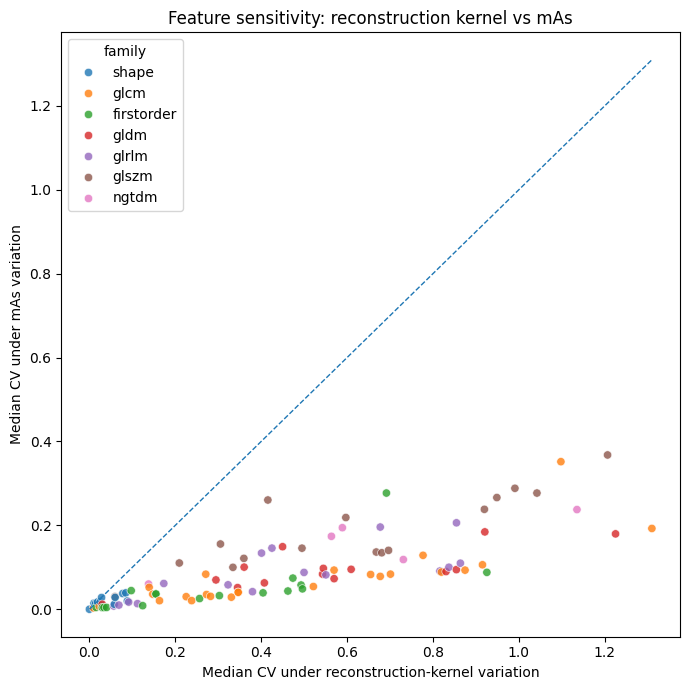

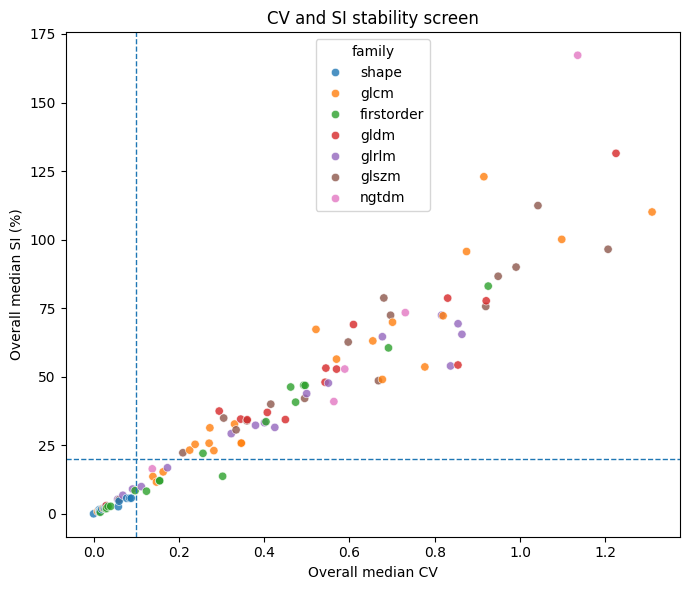

In [29]:
# Kernel vs mAs CV scatter
if {"cv_median_ReconstructionKernel", "cv_median_Exposure_mAs"}.issubset(df_overall.columns):
    plot_df = df_overall.dropna(
        subset=["cv_median_ReconstructionKernel", "cv_median_Exposure_mAs"]
    ).copy()

    plt.figure(figsize=(7, 7))
    sns.scatterplot(
        data=plot_df,
        x="cv_median_ReconstructionKernel",
        y="cv_median_Exposure_mAs",
        hue="family",
        alpha=0.8,
    )

    lim = max(
        plot_df["cv_median_Exposure_mAs"].max(),
        plot_df["cv_median_ReconstructionKernel"].max(),
    )
    plt.plot([0, lim], [0, lim], linestyle="--", linewidth=1)
    plt.xlabel("Median CV under reconstruction-kernel variation")
    plt.ylabel("Median CV under mAs variation")
    plt.title("Feature sensitivity: reconstruction kernel vs mAs")
    plt.tight_layout()
    plt.savefig(OUT_FIGURES / "plot_cv_kernel_vs_mas.png", dpi=300)
    plt.show()

# Overall CV vs SI scatter
if "overall_si_pct" in df_overall.columns and df_overall["overall_si_pct"].notna().any():
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=df_overall,
        x="overall_cv",
        y="overall_si_pct",
        hue="family",
        alpha=0.8,
    )
    plt.axvline(RELAXED_CV_THRESHOLD, linestyle="--", linewidth=1)
    plt.axhline(SI_THRESHOLD_PCT, linestyle="--", linewidth=1)
    plt.xlabel("Overall median CV")
    plt.ylabel("Overall median SI (%)")
    plt.title("CV and SI stability screen")
    plt.tight_layout()
    plt.savefig(OUT_FIGURES / "plot_overall_cv_vs_si.png", dpi=300)
    plt.show()

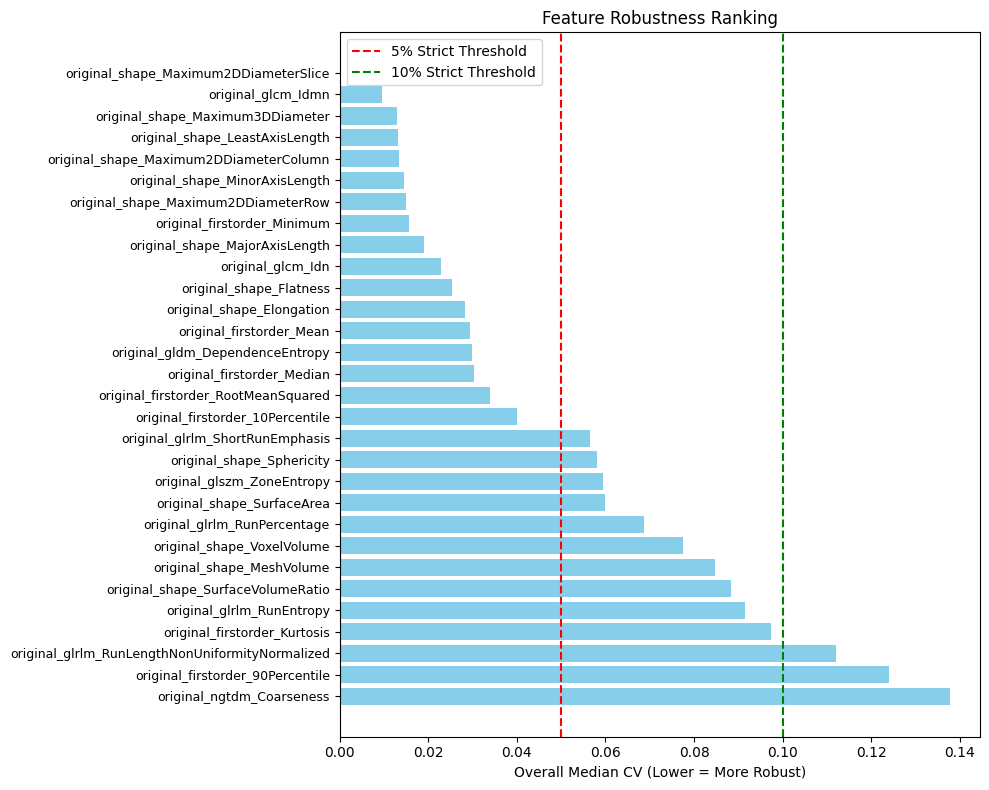

In [28]:
# ==========================================
# ANALYSIS A: The "Survivors" (Top)
# ==========================================
# These are the features you will recommend for clinical use.

df_top = df_overall.head(30).copy()

plt.figure(figsize=(10, 8))
# Invert Y-axis so #1 is at the top
plt.barh(range(len(df_top))[::-1], df_top["overall_cv"].values, color='skyblue')
plt.yticks(range(len(df_top))[::-1], df_top["feature"].values, fontsize=9)
plt.xlabel("Overall Median CV (Lower = More Robust)")
plt.title("Feature Robustness Ranking")
plt.axvline(x=0.05, color='r', linestyle='--', label='5% Strict Threshold') 
plt.axvline(x=0.1, color='green', linestyle='--', label='10% Strict Threshold') 
#plt.axvline(x=0.10, color='g', linestyle='--', label='10% Strict Threshold') 
plt.legend()
plt.tight_layout()
plt.savefig(OUT_FIGURES / "Robustness Ranking.png", dpi=300)
plt.show()


## 10. Blooming or volumetric edge-distortion analysis

In [30]:
# ============================================================
# Controlled Solid Acrylic blooming / volume-deviation analysis
# ============================================================

BLOOMING_LAYER = "Solid Acrylic"
BLOOMING_VOLUME_FEATURE = "original_shape_MeshVolume"

def compute_controlled_blooming_level_means(
    df_all: pd.DataFrame,
    volume_feature: str = BLOOMING_VOLUME_FEATURE,
    layer_name: str = BLOOMING_LAYER,
) -> pd.DataFrame:
    """
    Computes kernel-associated volume deviation in the Solid Acrylic layer.

    Important:
    This version first averages repeated scans within each target and kernel level.
    This avoids plotting repeated reference-kernel rows as nonzero deviations.
    """

    fixed_cols = FIXED_COLS_BY_PARAM["ReconstructionKernel"] + ["Layer"]

    df_layer = df_all[df_all["Layer"] == layer_name].copy()

    targets = build_targets(
        df_layer,
        param_col="ReconstructionKernel",
        fixed_cols=fixed_cols,
        min_series=MIN_SERIES_PER_TARGET,
    )

    rows = []

    for target_id, g in enumerate(targets):
        ref_kernel = choose_reference_level(g, "ReconstructionKernel")

        if ref_kernel is None:
            continue

        # Average repeated rows within the same kernel level
        level_means = (
            g.groupby("ReconstructionKernel", dropna=True)[volume_feature]
            .mean()
            .reset_index()
            .rename(columns={volume_feature: "volume_mean"})
        )

        if ref_kernel not in set(level_means["ReconstructionKernel"]):
            continue

        ref_value = float(
            level_means.loc[
                level_means["ReconstructionKernel"] == ref_kernel,
                "volume_mean"
            ].iloc[0]
        )

        if abs(ref_value) < SI_REF_EPS:
            continue

        metadata = {
            "Manufacturer": g["Manufacturer"].iloc[0],
            "Model": g["Model"].iloc[0],
            "KVP": g["KVP"].iloc[0],
            "Exposure_mAs": g["Exposure_mAs"].iloc[0],
            "SliceThickness": g["SliceThickness"].iloc[0],
            "PixelSpacing_x": g["PixelSpacing_x"].iloc[0],
            "PixelSpacing_y": g["PixelSpacing_y"].iloc[0],
            "Pitch": g["Pitch"].iloc[0],
        }

        for _, r in level_means.iterrows():
            kernel = r["ReconstructionKernel"]
            volume_mean = float(r["volume_mean"])

            deviation_pct = (volume_mean - ref_value) / ref_value * 100.0

            rows.append({
                "target_id": target_id,
                "Layer": layer_name,
                "ReconstructionKernel": kernel,
                "reference_kernel": ref_kernel,
                "volume_feature": volume_feature,
                "volume_mean": volume_mean,
                "reference_volume_mean": ref_value,
                "volume_deviation_pct": deviation_pct,
                "is_reference_kernel": kernel == ref_kernel,
                **metadata,
            })

    return pd.DataFrame(rows)


df_blooming = compute_controlled_blooming_level_means(df_out)

df_blooming.to_csv(
    OUT_BLOOMING / "blooming_solid_acrylic_kernel_level_mean_deviation.csv",
    index=False
)

print("Blooming rows:", len(df_blooming))
print("Targets used:", df_blooming["target_id"].nunique())
print("Reference kernels:")
print(df_blooming["reference_kernel"].value_counts())

Blooming rows: 30
Targets used: 6
Reference kernels:
reference_kernel
B30f        7
I30f        6
B           6
B31f        6
STANDARD    5
Name: count, dtype: int64


In [31]:
target_reference_summary = (
    df_blooming[["target_id", "reference_kernel"]]
    .drop_duplicates()
    ["reference_kernel"]
    .value_counts()
)

print("Targets used:", df_blooming["target_id"].nunique())
print("Target-level reference kernels:")
print(target_reference_summary)

Targets used: 6
Target-level reference kernels:
reference_kernel
B           2
STANDARD    1
I30f        1
B31f        1
B30f        1
Name: count, dtype: int64


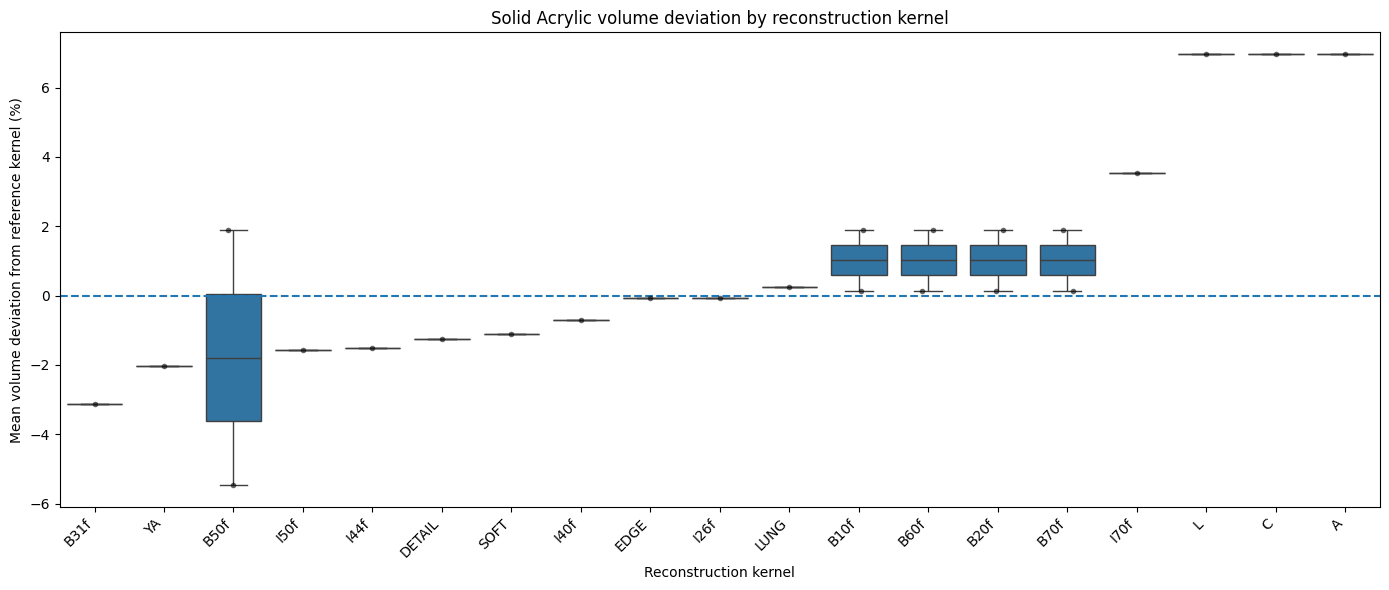

In [32]:
# ============================================================
# Plot blooming result
# ============================================================

plot_df = df_blooming[~df_blooming["is_reference_kernel"]].copy()

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=plot_df,
    x="ReconstructionKernel",
    y="volume_deviation_pct",
    order=plot_df.groupby("ReconstructionKernel")["volume_deviation_pct"]
                 .median()
                 .sort_values()
                 .index,
)

sns.stripplot(
    data=plot_df,
    x="ReconstructionKernel",
    y="volume_deviation_pct",
    order=plot_df.groupby("ReconstructionKernel")["volume_deviation_pct"]
                 .median()
                 .sort_values()
                 .index,
    color="black",
    alpha=0.6,
    size=4,
)

plt.axhline(0, linestyle="--")
plt.title("Solid Acrylic volume deviation by reconstruction kernel")
plt.xlabel("Reconstruction kernel")
plt.ylabel("Mean volume deviation from reference kernel (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    OUT_FIGURES / "blooming_solid_acrylic_kernel_level_mean_deviation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

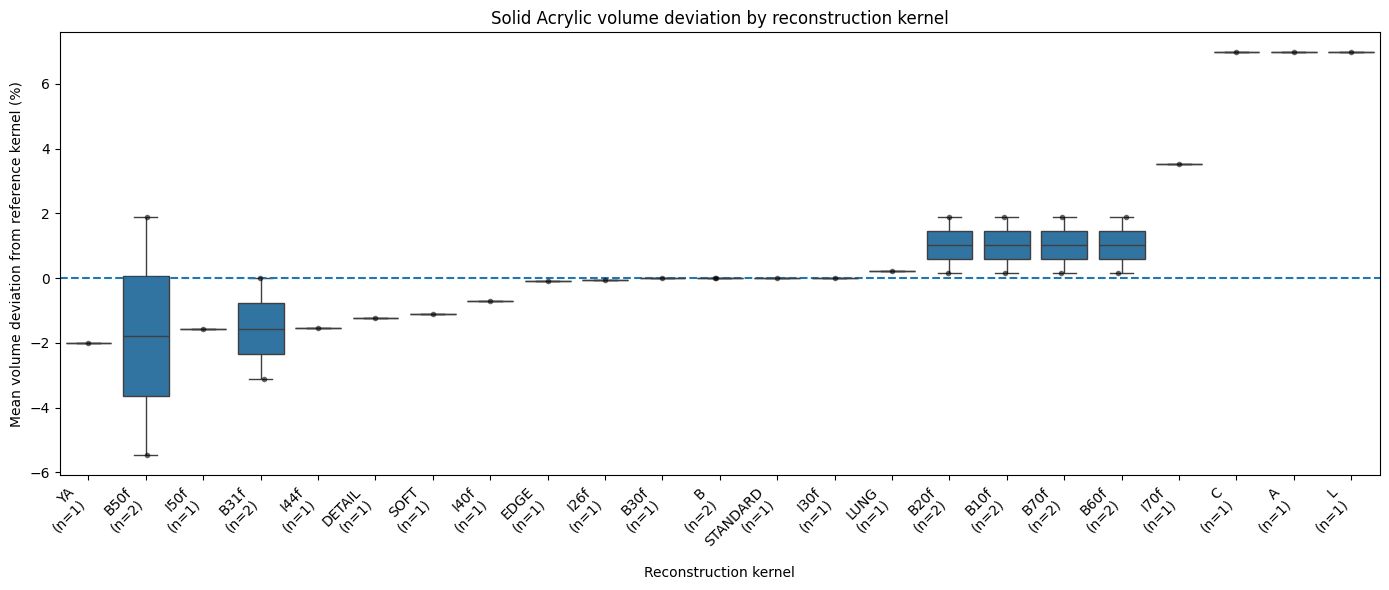

In [23]:
plot_df = df_blooming.copy()

kernel_order = (
    plot_df.groupby("ReconstructionKernel")["volume_deviation_pct"]
    .median()
    .sort_values()
    .index
)

kernel_counts = plot_df["ReconstructionKernel"].value_counts()

kernel_labels = [
    f"{k}\n(n={kernel_counts[k]})"
    for k in kernel_order
]

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=plot_df,
    x="ReconstructionKernel",
    y="volume_deviation_pct",
    order=kernel_order,
)

sns.stripplot(
    data=plot_df,
    x="ReconstructionKernel",
    y="volume_deviation_pct",
    order=kernel_order,
    color="black",
    alpha=0.6,
    size=4,
)

plt.axhline(0, linestyle="--")
plt.title("Solid Acrylic volume deviation by reconstruction kernel")
plt.xlabel("Reconstruction kernel")
plt.ylabel("Mean volume deviation from reference kernel (%)")
plt.xticks(
    ticks=range(len(kernel_order)),
    labels=kernel_labels,
    rotation=45,
    ha="right"
)
plt.tight_layout()
plt.show()

## 11. PCA using the CV-selected robust feature subset

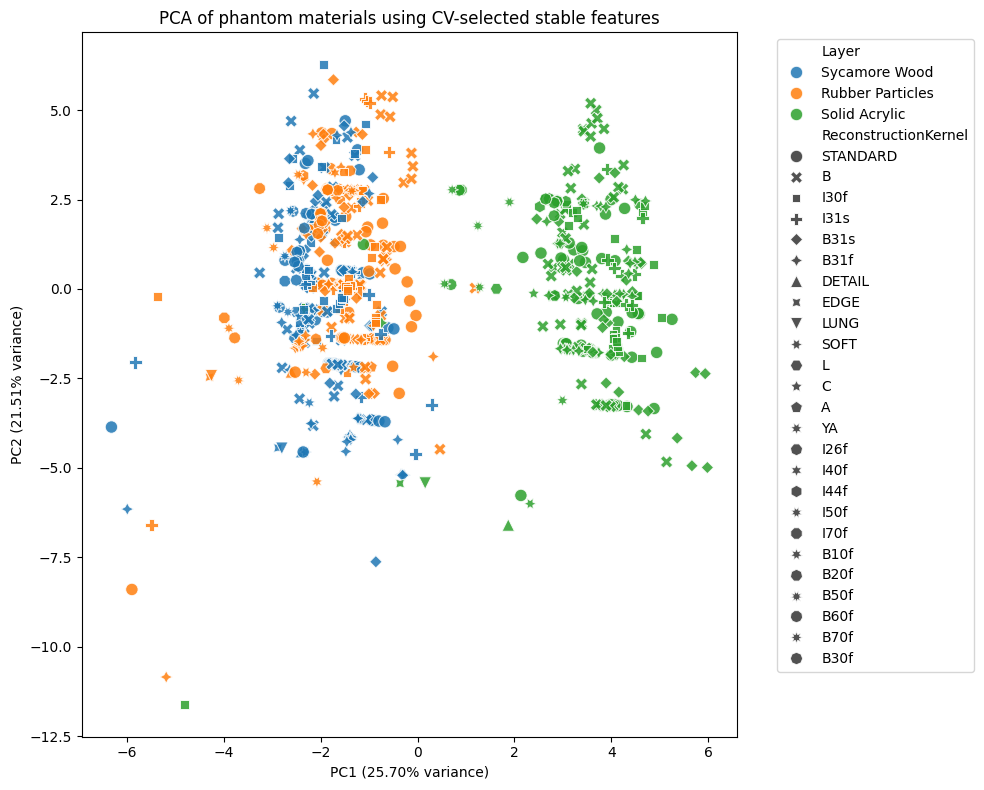

PCA features used: 27
PC1 + PC2 variance: 0.4720798972568009


In [24]:
# Primary PCA subset follows the thesis feature-selection logic: CV <= 0.10.
stable_features_cv = df_overall.loc[
    df_overall["stable_cv_le_0p10"], "feature"
].tolist()

# Optional sensitivity subset if you want a more conservative CV + SI PCA later.
stable_features_cv_si = df_overall.loc[
    df_overall["stable_cv_0p10_and_si_20pct"], "feature"
].tolist()

PCA_FEATURES = [f for f in stable_features_cv if f in df_out.columns]

plot_layers = ["Rubber Particles", "Sycamore Wood", "Solid Acrylic"]
pca_df = df_out[df_out["Layer"].isin(plot_layers)].copy()

if len(PCA_FEATURES) < 2:
    print("Not enough stable CV features for PCA.")
else:
    X = pca_df[PCA_FEATURES].replace([np.inf, -np.inf], np.nan).dropna()
    pca_meta = pca_df.loc[X.index, ["Layer", "ReconstructionKernel"]].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    X_pca = pca.fit_transform(X_scaled)

    pca_plot = pca_meta.copy()
    pca_plot["PC1"] = X_pca[:, 0]
    pca_plot["PC2"] = X_pca[:, 1]

    pca_plot.to_csv(OUT_PCA / "pca_scores_stable_cv.csv", index=False)

    pca_info = pd.DataFrame({
        "component": ["PC1", "PC2"],
        "explained_variance_ratio": pca.explained_variance_ratio_,
    })
    pca_info.to_csv(OUT_PCA / "pca_explained_variance_stable_cv.csv", index=False)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=pca_plot,
        x="PC1",
        y="PC2",
        hue="Layer",
        style="ReconstructionKernel",
        s=80,
        alpha=0.85,
    )
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.title("PCA of phantom materials using CV-selected stable features")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(OUT_FIGURES / "plot_pca_stable_cv.png", dpi=300)
    plt.show()

    print("PCA features used:", len(PCA_FEATURES))
    print("PC1 + PC2 variance:", float(pca.explained_variance_ratio_.sum()))

## 12. Run manifest for reproducibility

In [33]:
manifest = {
    "dataset_root": str(DATASET_ROOT),
    "out_dir": str(OUT_DIR),
    "radiomics_yaml": str(RADIOMICS_YAML),
    "reference_row_index": int(REFERENCE_ROW_INDEX),
    "mask_refine_hu": [MASK_REFINE_HU_LO, MASK_REFINE_HU_HI],
    "params_to_analyze": PARAMS_TO_ANALYZE,
    "fixed_cols_by_param": FIXED_COLS_BY_PARAM,
    "min_series_per_target": MIN_SERIES_PER_TARGET,
    "min_targets_required": MIN_TARGETS_REQUIRED,
    "cv_use_parameter_level_means": CV_USE_PARAMETER_LEVEL_MEANS,
    "strict_cv_threshold": STRICT_CV_THRESHOLD,
    "relaxed_cv_threshold": RELAXED_CV_THRESHOLD,
    "si_threshold_pct": SI_THRESHOLD_PCT,
    "si_reference_rule": {
        "Exposure_mAs": "highest mAs within controlled target group",
        "ReconstructionKernel": "preferred standard/soft kernel when available; otherwise most frequent kernel",
    },
    "n_rows_features_final": int(len(df_out)),
    "n_features_usable": int(len(feature_cols)),
    "n_stable_cv_0p05": int(df_overall["stable_cv_le_0p05"].sum()),
    "n_stable_cv_0p10": int(df_overall["stable_cv_le_0p10"].sum()),
    "n_stable_si_20pct": int(df_overall["stable_si_lt_20pct"].sum()),
    "n_stable_cv_si": int(df_overall["stable_cv_0p10_and_si_20pct"].sum()),
}

with open(OUT_MANIFEST / "run_manifest_phantom_cv_si.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved run manifest:", OUT_MANIFEST / "run_manifest_phantom_cv_si.json")

Saved run manifest: C:\Users\Ideanuodo\Desktop\Updated Code\outputs_clean\10_manifest\run_manifest_phantom_cv_si.json
